In [59]:
# Imports
import math
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image

Starting with a cosmology object. Start by making a curve with curvature density of $\Omega_{k} = 0$, also called a "flat cosmology." Hubble parameter of $70 km/s/Mpc$ and matter density $\Omega_{M} = 0.3$ at redshift 0. The FlatLambdaCDM cosmology then automatically infers that the dark energy density $\Omega_{\Lambda} = 0.7$, since $\Omega_{M}+\Omega_{\Lambda}+\Omega_{k}=1$ 

In [60]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# In this case we just need to define the matter density
# and hubble parameter at z=0.

# Note the default units for the hubble parameter H0 are km/s/Mpc.
# We will pass in a `Quantity` object with the units specified.

# Hubble parameter H0, matter density Om0
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Om0=0.3)

There are also built in cosmologies in astropy.

Now, create an example quantity to plot vs. redshift. This will use the angular diameter distance. Angular diameter distance is the physical transverse distane (e.g. the size of a galaxy) corresponding to a fixed angular separation on the sky.

The cell below calculates the angular diameter distance for a range of redshifts.

In [61]:
import numpy as np

zvals = np.arange(0, 6, 0.1)
dist = cosmo.angular_diameter_distance(zvals)

The array of redshifts have been passed to cosmo.angular_diameter_distance. It then produces a corresponding array of distance values with one for each redshift.

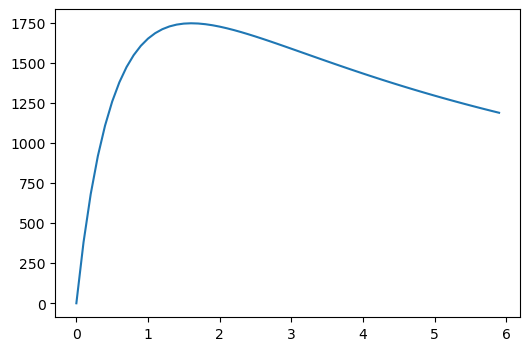

In [62]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)

You can check the units of the angular diameter distance by looking at the unit attribute.

In [63]:
dist.unit

Unit("Mpc")

Adding labels to the top axis.
Series of round age values where the axis ticks are. These may need to be tweaked for the redshift range to have evenly spaced ticks.

In [64]:
ages = np.array([13, 10, 8, 6, 5, 4, 3, 2, 1.5, 1.2, 1]) * u.Gyr

Links the redshift and age axes. A redshift needs to be found for each age. The function z_at_value does this.

In [65]:
from astropy.cosmology import z_at_value
ageticks = [z_at_value(cosmo.age, age) for age in ages]

Create a second axis, then set the tick positions using those values

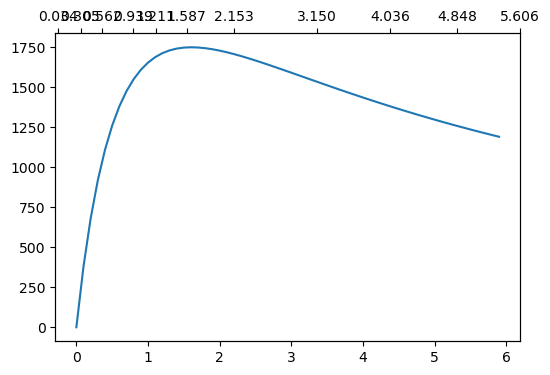

In [66]:
fig = plt.figure(figsize = (6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)
ax2 = ax.twiny() # Creates twin axes sharing the y-axis
ax2.set_xticks(ageticks)

The ticks on the top axis are labeled in redshift, not the age. By setting the tick labels by hand, it can be fixed.

[Text(0.03426542424730718, 1, '13'),
 Text(0.3052996987053907, 1, '10'),
 Text(0.5622761997285901, 1, '8'),
 Text(0.9394313081990149, 1, '6'),
 Text(1.2114538180402323, 1, '5'),
 Text(1.5867361300254532, 1, '4'),
 Text(2.153211270001333, 1, '3'),
 Text(3.1503817535239276, 1, '2'),
 Text(4.035713900198318, 1, '1.5'),
 Text(4.84767084618423, 1, '1.2'),
 Text(5.606047443188422, 1, '1')]

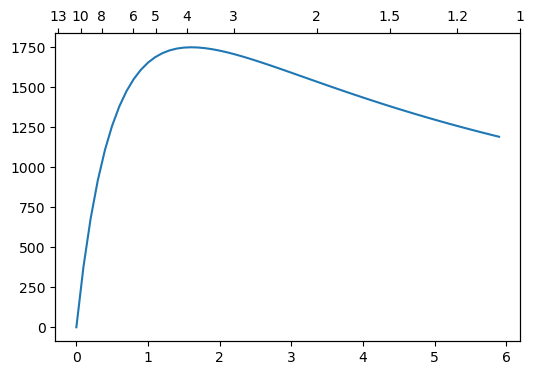

In [67]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(["{:g}".format(age) for age in ages.value])

The age of the universe at z = 0 should be ~13 Gyr. They may not line up properly in the plot above depending on your setup. To make sure the top and bottom axes have the same redshift limit:

(0.0, 5.9)

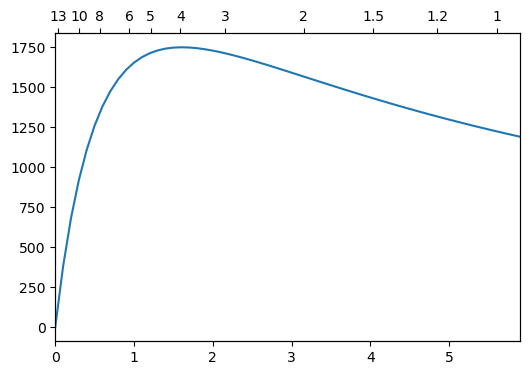

In [68]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(["{:g}".format(age) for age in ages.value])
zmin, zmax = 0.0, 5.9
ax.set_xlim(zmin, zmax)
ax2.set_xlim(zmin, zmax)

Label axes and add minor ticks. Tweak the y-axis limits to avoid putting labels right near the top of the plot.

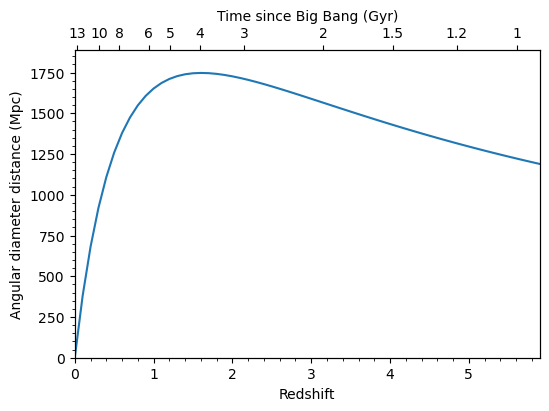

In [69]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(["{:g}".format(age) for age in ages.value])
zmin, zmax = 0, 5.9
ax.set_xlim(zmin, zmax)
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel("Time since Big Bang (Gyr)")
ax.set_xlabel("Redshift")
ax.set_ylabel("Angular diameter distance (Mpc)")
ax.set_ylim(0, 1890)
ax.minorticks_on()

Add the angular diameter distance for a different cosmology, Planck 2013, for comparison.

(0.0, 1890.0)

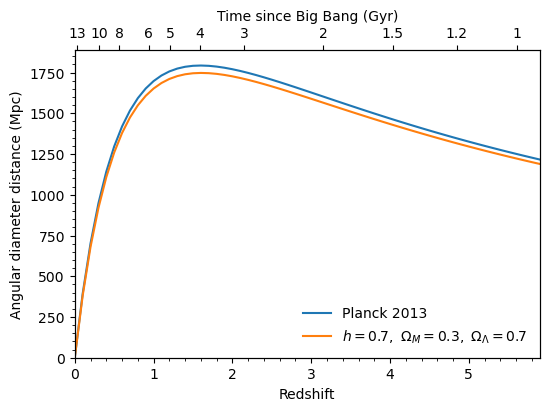

In [70]:
from astropy.cosmology import Planck13

dist2 = Planck13.angular_diameter_distance(zvals)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist2, label="Planck 2013")
ax.plot(zvals, dist, label="$h=0.7,\ \Omega_M=0.3,\ \Omega_\Lambda=0.7$")
ax.legend(frameon=0, loc="lower right")
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(["{:g}".format(age) for age in ages.value])
zmin, zmax = 0.0, 5.9
ax.set_xlim(zmin, zmax)
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel("Time since Big Bang (Gyr)")
ax.set_xlabel("Redshift")
ax.set_ylabel("Angular diameter distance (Mpc)")
ax.minorticks_on()
ax.set_ylim(0, 1890)

Finally, save the figure to a png file.

In [23]:
fig.savefig("ang_dist.png", dpi = 200, bbox_inches="tight")

bbox_inches='tight' automatically trims any whitespace from around the plot edges.

Well, almost done. Notice that we calculated the times on the upper axis using the original cosmology, not the new cosmology based on the Planck 2013 results. So strictly speaking, this axis applies only to the original cosmology, although the difference between the two is small. As an exercise, you can try plot two different upper axes, slightly offset from each other, to show the times corresponding to each cosmology. Take a look at the first answer to this question on Stack Overflow (https://stackoverflow.com/questions/7733693/overlay-plots-with-different-scales) for some hints on how to go about this.

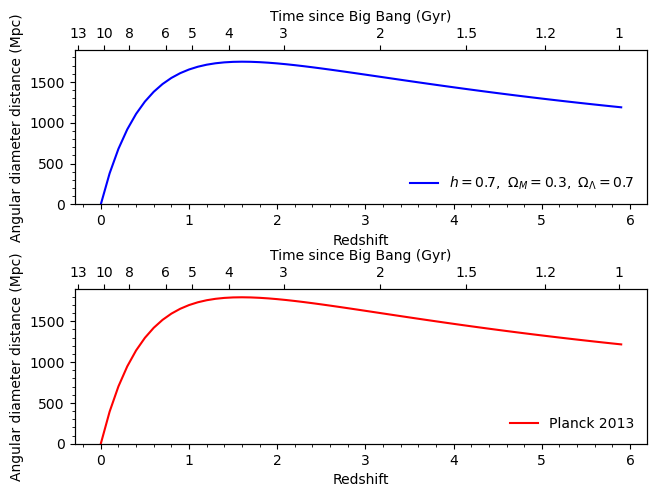

In [85]:
# 2 subplots ax1 and ax2, plotted redshift vs. angular distance.
fig1, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(zvals, dist, label="$h=0.7,\ \Omega_M=0.3,\ \Omega_\Lambda=0.7$", c="b")
ax2.plot(zvals, dist2, label="Planck 2013", c="r")
ax1.legend(frameon=0, loc="lower right")
ax2.legend(frameon=0, loc="lower right")
# Create a second set of x axis for both plots, ax12 and ax22
ax12 = ax1.twiny()
ax22 = ax2.twiny()
# Set ax12 and ax22 ticks to Time since Big Bang (Gyr)
ax12.set_xticks(ageticks)
ax22.set_xticks(ageticks)
ax12.set_xticklabels(["{:g}".format(age) for age in ages.value])
ax22.set_xticklabels(["{:g}".format(age) for age in ages.value])
ax12.set_xlim(zmin, zmax)
ax22.set_xlim(zmin, zmax)
ax12.set_xlabel("Time since Big Bang (Gyr)")
ax22.set_xlabel("Time since Big Bang (Gyr)")
ax1.set_xlabel("Redshift")
ax2.set_xlabel("Redshift")
ax1.set_ylabel("Angular diameter distance (Mpc)")
ax1.minorticks_on()
ax1.set_ylim(0, 1890)
ax2.set_ylabel("Angular diameter distance (Mpc)")
ax2.minorticks_on()
ax2.set_ylim(0, 1890)
fig1.tight_layout(pad=0.1) 
fig1.savefig("ang_dist_seperate.png", dpi = 200, bbox_inches="tight")